# CIFAR-10 자연영상데이터셋

In [1]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
# TensorFlow(딥러닝 라이브러리)를 불러온다
import tensorflow as tf
# Keras에 들어있는 데이터셋 모음 (MNIST 같은 것들이 있
import tensorflow.keras.datasets as ds
# 그래프나 이미지를 화면에 그리기 위한 라이브러리
import matplotlib.pyplot as plt


In [6]:
# ------------------------------------------
# MNIST 손글씨 숫자 데이터를 불러온다
# ------------------------------------------
# x_train : 학습용 숫자 이미지들
# y_train : 학습용 숫자의 정답 (0~9)
# x_test  : 테스트용 숫자 이미지들
# y_test  : 테스트용 숫자의 정답
(x_train,y_train),(x_test,y_test)=ds.mnist.load_data()


# ------------------------------------------
# 불러온 데이터의 크기를 출력해 본다
# ------------------------------------------
# x_train.shape → (60000, 28, 28)
#   → 28x28 크기의 이미지가 60000장
# y_train.shape → (60000,)
#   → 정답 숫자가 60000개
# x_test.shape → (10000, 28, 28)
# y_test.shape → (10000,)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [7]:
# ------------------------------------------
# 그림을 그릴 큰 도화지를 만든다
# ------------------------------------------
# figsize=(24,3) → 가로로 길고 세로로 얇은 그림판

plt.figure(figsize=(24,3))

# 전체 그림의 제목을 "MNIST"로 크게 표시
plt.suptitle('MNIST',fontsize=30)

Text(0.5, 0.98, 'MNIST')

<Figure size 2400x300 with 0 Axes>

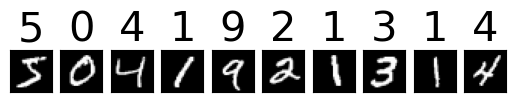

In [8]:

# ------------------------------------------
# 처음 10개의 숫자 이미지를 화면에 출력
# ------------------------------------------
for i in range(10): # i = 0 ~ 9까지 반복
    # 1행 10열짜리 공간을 만들고
    # i+1 번째 칸에 그림을 그리겠다
    plt.subplot(1,10,i+1)
    # x_train[i] = i번째 숫자 이미지
    # cmap='gray' → 흑백 이미지로 표시
    plt.imshow(x_train[i],cmap='gray')
    # x축 눈금 제거 (이미지니까 필요 없음)
      # y축 눈금 제거
    plt.xticks([]);plt.yticks([])
    # 해당 이미지의 실제 숫자를 제목으로 표시
    # y_train[i] → 이 이미지가 어떤 숫자인지
    plt.title(str(y_train[i]),fontsize=30)

In [ ]:
# CIFAR-10 데이터셋을 불러오기
# (동물, 자동차, 비행기 같은 컬러 사진이 들어 있음)
(x_train,y_train),(x_test,y_test)=ds.cifar10.load_data()

# 불러온 데이터의 크기 출력
# x_train.shape → (50000, 32, 32, 3)  → 학습용 이미지 5만 장, 크기 32x32, RGB(3색)
# y_train.shape → (50000, 1)         → 각 이미지의 정답(0~9)
# x_test.shape  → (10000, 32, 32, 3)  → 테스트 이미지 1만 장
# y_test.shape  → (10000, 1)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [ ]:
# ---------------------------------------
# 숫자(0~9)를 사람이 읽을 수 있는 이름으로 바꾸는 표
# ---------------------------------------
# 예)
# 0 → airplane
# 1 → car
# 2 → bird
# 3 → cat
# ...

class_names=['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

In [ ]:
# ---------------------------------------
# 그림을 그릴 큰 화면(도화지) 만들기
# ---------------------------------------
plt.figure(figsize=(24,3))   # 가로 24, 세로 3 크기의 큰 화면
plt.suptitle('CIFAR-10',fontsize=30)  # 위에 "CIFAR-10" 제목 표시

Text(0.5, 0.98, 'CIFAR-10')

<Figure size 2400x300 with 0 Axes>

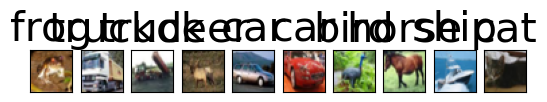

In [ ]:
# ---------------------------------------
# 처음 10개의 이미지를 화면에 보여주기
# ---------------------------------------

for i in range(10): # i = 0부터 9까지 (사진 10장)
    # 1행 10열짜리 칸을 만들고
    # i+1 번째 칸에 그림을 그린다
    plt.subplot(1,10,i+1)
     # i번째 컬러 이미지를 화면에 표시
    plt.imshow(x_train[i])
    # x축과 y축 숫자(눈금) 제거 → 사진만 깔끔하게 보이게
    plt.xticks([]);plt.yticks([])
    
    # -----------------------------------
    # 이 이미지가 무엇인지 제목으로 표시
    # -----------------------------------
    # y_train[i,0] → i번째 이미지가 어떤 물체인지 숫자 (예: 3)
    # class_names[3] → 'cat'
    # 즉, 숫자를 이름으로 바꿔서 제목에 표시
    plt.title(class_names[y_train[i,0]],fontsize=30)




In [17]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [13]:
print(y_train)
print(class_names[0])

[[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]
airplane


### 다층 퍼셉트론으로 MNIST 인식하기(SGD 옵티마이저)

In [ ]:
# 숫자 계산을 위한 라이브러리
import numpy as np
# 딥러닝을 위한 TensorFlow
import tensorflow as tf
# MNIST 같은 데이터셋이 들어 있는 곳
import tensorflow.keras.datasets as ds

# -----------------------------------------
# 신경망(모델) 만들 때 필요한 도구들
# -----------------------------------------
from tensorflow.keras.models import Sequential # 층을 차례대로 쌓는 모델
from tensorflow.keras.layers import Dense # 가장 기본적인 신경망 층
from tensorflow.keras.optimizers import SGD  # 학습할 때 사용하는 최적화 방법




# -----------------------------------------
# MNIST 숫자 데이터 불러오기
# -----------------------------------------
# x_train : 학습용 숫자 이미지 (60000장)
# y_train : 학습용 정답 숫자
# x_test  : 테스트용 숫자 이미지 (10000장)
# y_test  : 테스트용 정답 숫자
(x_train,y_train),(x_test,y_test)=ds.mnist.load_data()

In [ ]:
# -----------------------------------------
# 이미지 모양 바꾸기 (28x28 → 784)
# -----------------------------------------
# MNIST 한 장의 크기: 28 x 28
# 28 x 28 = 784
# → 네모 그림을 길게 한 줄(784칸)로 펴는 것
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)


# -----------------------------------------
# 픽셀값을 0~1 사이로 바꾸기
# -----------------------------------------
# 원래 픽셀 값은 0~255
# 이를 255로 나누어 0~1 사이로 만듦
# 신경망이 계산하기 쉬워짐
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0



# -----------------------------------------
# 정답 숫자를 딥러닝용으로 변환 (원핫 인코딩)
# -----------------------------------------
# 예)
# 3 → [0,0,0,1,0,0,0,0,0,0]
# 7 → [0,0,0,0,0,0,0,1,0,0]
# 숫자를 "확률 형태"로 바꿔 주는 과정
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)



In [ ]:
# ---------------------------------------
# 1️⃣ 빈 신경망(모델) 만들기
# ---------------------------------------
# Sequential = 층을 위에서 아래로 차례대로 쌓는 신경망
mlp=Sequential()

# ---------------------------------------
# 2️⃣ 첫 번째 신경망 층 (은닉층)
# ---------------------------------------
# Dense = 모든 입력과 연결된 신경망 층
# units=512 → 뉴런(뇌세포) 512개
# activation='tanh' → 뉴런이 생각하는 방식
# input_shape=(784,) → MNIST 한 장은 숫자 784개
mlp.add(Dense(units=512,activation='tanh',input_shape=(784,)))

# ---------------------------------------
# 3️⃣ 출력층 (정답을 만드는 층)
# ---------------------------------------
# units=10 → 0~9 숫자 10개
# softmax → 각 숫자가 될 확률로 출력
mlp.add(Dense(units=10,activation='softmax'))

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ---------------------------------------
# 4️⃣ 학습 방법 설정
# ---------------------------------------
# loss='MSE' → 예측과 정답의 차이를 계산하는 방법
# SGD → 조금씩 정답 방향으로 고쳐가는 방법
# learning_rate=0.01 → 고치는 속도
# metrics=['accuracy'] → 맞춘 비율(정확도)도 같이 계산
mlp.compile(loss='MSE',optimizer=SGD(learning_rate=0.01),metrics=['accuracy'])

In [ ]:
# ---------------------------------------
# 5️⃣ 신경망 학습시키기
# ---------------------------------------
# x_train, y_train → 연습 문제
# batch_size=128 → 한 번에 128장씩 보고 학습
# epochs=50 → 전체 데이터를 50번 반복해서 공부
# validation_data → 시험 문제로 중간 점검
# verbose=2 → 학습 과정을 화면에 출력

mlp.fit(x_train,y_train,batch_size=128,epochs=50,validation_data=(x_test,y_test),verbose=2)

Epoch 1/50
469/469 - 2s - 3ms/step - accuracy: 0.1540 - loss: 0.0897 - val_accuracy: 0.2471 - val_loss: 0.0872
Epoch 2/50
469/469 - 1s - 2ms/step - accuracy: 0.3337 - loss: 0.0839 - val_accuracy: 0.4080 - val_loss: 0.0807
Epoch 3/50
469/469 - 1s - 2ms/step - accuracy: 0.4723 - loss: 0.0771 - val_accuracy: 0.5341 - val_loss: 0.0735
Epoch 4/50
469/469 - 1s - 2ms/step - accuracy: 0.5714 - loss: 0.0699 - val_accuracy: 0.6220 - val_loss: 0.0662
Epoch 5/50
469/469 - 1s - 2ms/step - accuracy: 0.6421 - loss: 0.0630 - val_accuracy: 0.6732 - val_loss: 0.0596
Epoch 6/50
469/469 - 1s - 2ms/step - accuracy: 0.6844 - loss: 0.0571 - val_accuracy: 0.7062 - val_loss: 0.0540
Epoch 7/50
469/469 - 1s - 2ms/step - accuracy: 0.7123 - loss: 0.0522 - val_accuracy: 0.7301 - val_loss: 0.0496
Epoch 8/50
469/469 - 1s - 2ms/step - accuracy: 0.7330 - loss: 0.0483 - val_accuracy: 0.7484 - val_loss: 0.0460
Epoch 9/50
469/469 - 1s - 2ms/step - accuracy: 0.7481 - loss: 0.0452 - val_accuracy: 0.7623 - val_loss: 0.0432
E

In [ ]:
# ---------------------------------------
# 6️⃣ 시험 보기 (성능 평가)
# ---------------------------------------
# 테스트 데이터를 이용해 정확도 측정
res=mlp.evaluate(x_test,y_test,verbose=0)


# ---------------------------------------
# 7️⃣ 정확도 출력
# ---------------------------------------
# res[1] → accuracy 값
# ×100 → 퍼센트로 변환
print("정확률=",res[1]*100)

정확률= 89.62000012397766


## Adam 옵티마이저를 사용하여 성능 향상

In [20]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

(x_train,y_train),(x_test,y_test)=ds.mnist.load_data()

In [21]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)

In [22]:
mlp=Sequential()
mlp.add(Dense(units=512,activation='tanh',input_shape=(784,)))
mlp.add(Dense(units=10,activation='softmax'))

mlp.compile(loss='MSE',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

mlp.fit(x_train,y_train,batch_size=128,epochs=50,validation_data=(x_test,y_test),verbose=2)

Epoch 1/50


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 - 2s - 4ms/step - accuracy: 0.8990 - loss: 0.0151 - val_accuracy: 0.9347 - val_loss: 0.0101
Epoch 2/50
469/469 - 1s - 3ms/step - accuracy: 0.9414 - loss: 0.0091 - val_accuracy: 0.9515 - val_loss: 0.0076
Epoch 3/50
469/469 - 1s - 3ms/step - accuracy: 0.9576 - loss: 0.0067 - val_accuracy: 0.9577 - val_loss: 0.0064
Epoch 4/50
469/469 - 1s - 3ms/step - accuracy: 0.9683 - loss: 0.0052 - val_accuracy: 0.9642 - val_loss: 0.0055
Epoch 5/50
469/469 - 1s - 3ms/step - accuracy: 0.9740 - loss: 0.0042 - val_accuracy: 0.9664 - val_loss: 0.0052
Epoch 6/50
469/469 - 1s - 3ms/step - accuracy: 0.9791 - loss: 0.0035 - val_accuracy: 0.9713 - val_loss: 0.0045
Epoch 7/50
469/469 - 1s - 3ms/step - accuracy: 0.9828 - loss: 0.0029 - val_accuracy: 0.9736 - val_loss: 0.0041
Epoch 8/50
469/469 - 1s - 3ms/step - accuracy: 0.9859 - loss: 0.0024 - val_accuracy: 0.9756 - val_loss: 0.0038
Epoch 9/50
469/469 - 1s - 3ms/step - accuracy: 0.9883 - loss: 0.0021 - val_accuracy: 0.9759 - val_loss: 0.0038
Epoch 10/50


In [23]:
res=mlp.evaluate(x_test,y_test,verbose=0)
print('정확률=',res[1]*100)

정확률= 98.25999736785889


##  SGD와 Adam 성능을 그래프로 비교

In [30]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD,Adam

(x_train,y_train),(x_test,y_test)=ds.mnist.load_data()

In [31]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)

In [32]:
mlp_sgd=Sequential()
mlp_sgd.add(Dense(units=512,activation='tanh',input_shape=(784,)))
mlp_sgd.add(Dense(units=10,activation='softmax'))
mlp_sgd.compile(loss='MSE',optimizer=SGD(learning_rate=0.01),metrics=['accuracy'])

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
hist_sgd=mlp_sgd.fit(x_train,y_train,batch_size=128,epochs=50,validation_data=(x_test,y_test),verbose=2)

Epoch 1/50
469/469 - 1s - 3ms/step - accuracy: 0.1475 - loss: 0.0896 - val_accuracy: 0.2346 - val_loss: 0.0863
Epoch 2/50
469/469 - 1s - 2ms/step - accuracy: 0.3214 - loss: 0.0831 - val_accuracy: 0.4100 - val_loss: 0.0798
Epoch 3/50
469/469 - 1s - 2ms/step - accuracy: 0.4757 - loss: 0.0764 - val_accuracy: 0.5315 - val_loss: 0.0726
Epoch 4/50
469/469 - 1s - 2ms/step - accuracy: 0.5667 - loss: 0.0693 - val_accuracy: 0.5985 - val_loss: 0.0654
Epoch 5/50
469/469 - 1s - 2ms/step - accuracy: 0.6174 - loss: 0.0626 - val_accuracy: 0.6439 - val_loss: 0.0591
Epoch 6/50
469/469 - 1s - 2ms/step - accuracy: 0.6537 - loss: 0.0570 - val_accuracy: 0.6801 - val_loss: 0.0539
Epoch 7/50
469/469 - 1s - 2ms/step - accuracy: 0.6887 - loss: 0.0524 - val_accuracy: 0.7178 - val_loss: 0.0496
Epoch 8/50
469/469 - 1s - 2ms/step - accuracy: 0.7235 - loss: 0.0485 - val_accuracy: 0.7536 - val_loss: 0.0459
Epoch 9/50
469/469 - 1s - 2ms/step - accuracy: 0.7529 - loss: 0.0452 - val_accuracy: 0.7767 - val_loss: 0.0427
E

In [36]:
print("SGD 정확률=",mlp_sgd.evaluate(x_test,y_test,verbose=0)[1]*100)

SGD 정확률= 89.50999975204468


In [37]:
mlp_adam=Sequential()
mlp_adam.add(Dense(units=512,activation='tanh',input_shape=(784,)))
mlp_adam.add(Dense(units=10,activation='softmax'))

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
mlp_adam.compile(loss='MSE',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

In [39]:
hist_adam=mlp_adam.fit(x_train,y_train,batch_size=128,epochs=50,validation_data=(x_test,y_test),verbose=2)

Epoch 1/50
469/469 - 2s - 4ms/step - accuracy: 0.9023 - loss: 0.0148 - val_accuracy: 0.9344 - val_loss: 0.0101
Epoch 2/50
469/469 - 1s - 3ms/step - accuracy: 0.9428 - loss: 0.0088 - val_accuracy: 0.9537 - val_loss: 0.0073
Epoch 3/50
469/469 - 1s - 3ms/step - accuracy: 0.9589 - loss: 0.0064 - val_accuracy: 0.9615 - val_loss: 0.0060
Epoch 4/50
469/469 - 1s - 3ms/step - accuracy: 0.9691 - loss: 0.0049 - val_accuracy: 0.9656 - val_loss: 0.0052
Epoch 5/50
469/469 - 1s - 3ms/step - accuracy: 0.9758 - loss: 0.0040 - val_accuracy: 0.9710 - val_loss: 0.0045
Epoch 6/50
469/469 - 1s - 3ms/step - accuracy: 0.9797 - loss: 0.0034 - val_accuracy: 0.9716 - val_loss: 0.0044
Epoch 7/50
469/469 - 1s - 3ms/step - accuracy: 0.9833 - loss: 0.0028 - val_accuracy: 0.9744 - val_loss: 0.0039
Epoch 8/50
469/469 - 1s - 3ms/step - accuracy: 0.9863 - loss: 0.0024 - val_accuracy: 0.9762 - val_loss: 0.0037
Epoch 9/50
469/469 - 1s - 3ms/step - accuracy: 0.9883 - loss: 0.0020 - val_accuracy: 0.9731 - val_loss: 0.0042
E

In [40]:
print("Adam 정확률=",mlp_adam.evaluate(x_test,y_test,verbose=0)[1]*100)


Adam 정확률= 97.9099988937378


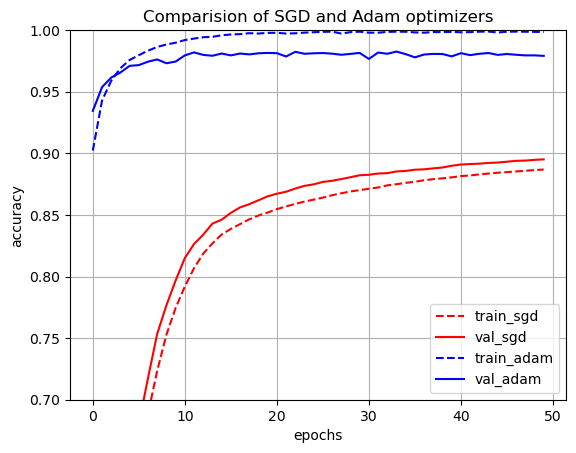

In [43]:
import matplotlib.pyplot as plt

plt.plot(hist_sgd.history['accuracy'],'r--')
plt.plot(hist_sgd.history['val_accuracy'],'r')
plt.plot(hist_adam.history['accuracy'],'b--')
plt.plot(hist_adam.history['val_accuracy'],'b')
plt.title('Comparision of SGD and Adam optimizers')
plt.ylim((0.7,1.0))
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train_sgd','val_sgd','train_adam','val_adam'])
plt.grid()
plt.show()

# 하이퍼 매개변수 다루기

## 깊은 다층 퍼셉트론으로 MNIST인식

In [44]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [45]:
(x_train,y_train),(x_test,y_test)=ds.mnist.load_data()

In [46]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)

In [48]:
dmlp=Sequential()
dmlp.add(Dense(units=1024,activation='relu',input_shape=(784,)))
dmlp.add(Dense(units=512,activation='relu'))
dmlp.add(Dense(units=512,activation='relu'))
dmlp.add(Dense(units=10,activation='softmax'))

In [49]:
dmlp.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])

In [50]:
hist=dmlp.fit(x_train,y_train,batch_size=128,epochs=50,validation_data=(x_test,y_test),verbose=2)

Epoch 1/50
469/469 - 5s - 11ms/step - accuracy: 0.8994 - loss: 0.3973 - val_accuracy: 0.9475 - val_loss: 0.1715
Epoch 2/50
469/469 - 4s - 9ms/step - accuracy: 0.9586 - loss: 0.1444 - val_accuracy: 0.9645 - val_loss: 0.1179
Epoch 3/50
469/469 - 4s - 8ms/step - accuracy: 0.9718 - loss: 0.0975 - val_accuracy: 0.9702 - val_loss: 0.0944
Epoch 4/50
469/469 - 4s - 8ms/step - accuracy: 0.9790 - loss: 0.0709 - val_accuracy: 0.9725 - val_loss: 0.0847
Epoch 5/50
469/469 - 4s - 8ms/step - accuracy: 0.9847 - loss: 0.0523 - val_accuracy: 0.9779 - val_loss: 0.0707
Epoch 6/50
469/469 - 3s - 7ms/step - accuracy: 0.9887 - loss: 0.0399 - val_accuracy: 0.9787 - val_loss: 0.0644
Epoch 7/50
469/469 - 4s - 8ms/step - accuracy: 0.9915 - loss: 0.0307 - val_accuracy: 0.9794 - val_loss: 0.0650
Epoch 8/50
469/469 - 4s - 8ms/step - accuracy: 0.9938 - loss: 0.0231 - val_accuracy: 0.9793 - val_loss: 0.0651
Epoch 9/50
469/469 - 4s - 8ms/step - accuracy: 0.9961 - loss: 0.0164 - val_accuracy: 0.9810 - val_loss: 0.0639


In [51]:
print("정확률=",dmlp.evaluate(x_test,y_test,verbose=0)[1]*100)


정확률= 98.07999730110168


In [52]:
dmlp.save('dmlp_trained.h5')

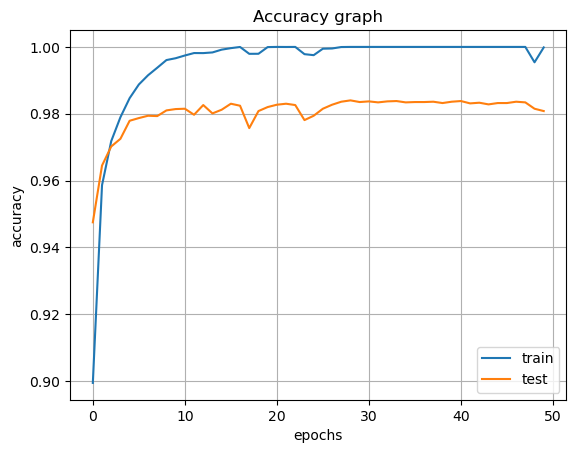

In [53]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train','test'])
plt.grid()
plt.show()

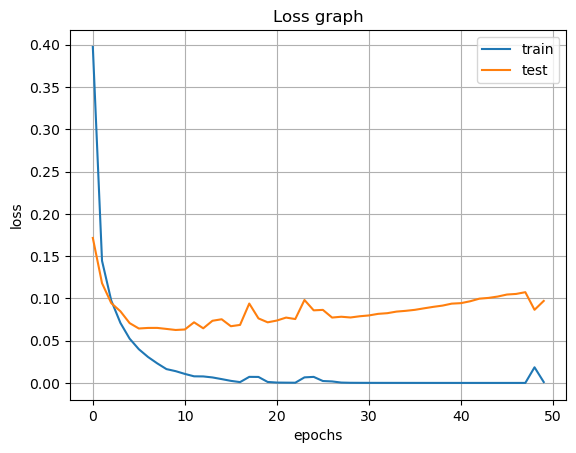

In [54]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss graph')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','test'])
plt.grid()
plt.show()

In [66]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [67]:
(x_train,y_train),(x_test,y_test)=ds.cifar10.load_data()

In [69]:
x_train=x_train.reshape(50000,3072)
x_test=x_test.reshape(10000,3072)
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)

In [70]:
dmlp=Sequential()
dmlp.add(Dense(units=1024,activation='relu',input_shape=(3072,)))
dmlp.add(Dense(units=512,activation='relu'))
dmlp.add(Dense(units=512,activation='relu'))
dmlp.add(Dense(units=10,activation='softmax'))

dmlp.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
hist=dmlp.fit(x_train,y_train,batch_size=128,epochs=50,validation_data=(x_test,y_test),verbose=2)

Epoch 1/50
391/391 - 6s - 15ms/step - accuracy: 0.3504 - loss: 1.8165 - val_accuracy: 0.4118 - val_loss: 1.6585
Epoch 2/50
391/391 - 5s - 13ms/step - accuracy: 0.4247 - loss: 1.6212 - val_accuracy: 0.4439 - val_loss: 1.5560
Epoch 3/50
391/391 - 5s - 13ms/step - accuracy: 0.4594 - loss: 1.5271 - val_accuracy: 0.4693 - val_loss: 1.5025
Epoch 4/50
391/391 - 4s - 11ms/step - accuracy: 0.4788 - loss: 1.4705 - val_accuracy: 0.4653 - val_loss: 1.4794
Epoch 5/50
391/391 - 5s - 13ms/step - accuracy: 0.4962 - loss: 1.4220 - val_accuracy: 0.4818 - val_loss: 1.4543
Epoch 6/50
391/391 - 5s - 14ms/step - accuracy: 0.5122 - loss: 1.3755 - val_accuracy: 0.4886 - val_loss: 1.4477
Epoch 7/50
391/391 - 5s - 13ms/step - accuracy: 0.5267 - loss: 1.3381 - val_accuracy: 0.4995 - val_loss: 1.4103
Epoch 8/50
391/391 - 5s - 13ms/step - accuracy: 0.5434 - loss: 1.2975 - val_accuracy: 0.5150 - val_loss: 1.3632
Epoch 9/50
391/391 - 7s - 17ms/step - accuracy: 0.5529 - loss: 1.2650 - val_accuracy: 0.5021 - val_loss:

In [ ]:
print("정확률=",dmlp.evaluate(x_test,y_test,verbose=0)[1]*100)

# dmlp.save('dmlp_trained.h5')

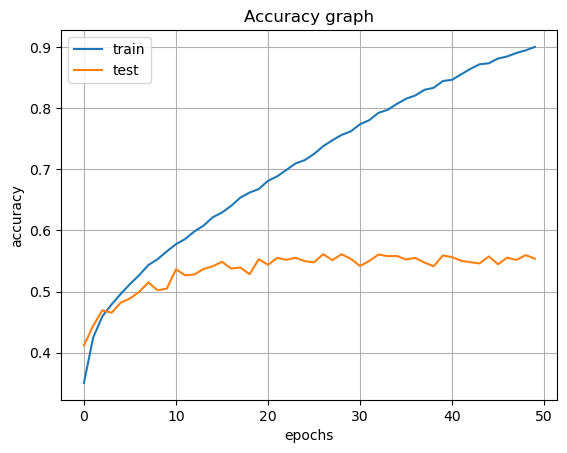

In [73]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train','test'])
plt.grid()
plt.show()